In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv", index_col=False)

In [4]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_df = data[all_site_cols].copy().astype(str).apply(lambda x: x.str.strip())
temp_df = temp_df.replace(['', 'nan', 'None', 'nan.0'], '0')

temp_df = temp_df.astype(float)

has_site_mask = (temp_df > 0).any(axis=1)

site_samples = data[has_site_mask].copy()

print(f"原始樣本數: {len(data)}")
print(f"至少標註一個部位的樣本數: {len(site_samples)}")
print(f"被排除掉的『全空/全0』樣本數: {len(data) - len(site_samples)}")


原始樣本數: 27968
至少標註一個部位的樣本數: 11880
被排除掉的『全空/全0』樣本數: 16088


In [5]:
len(site_samples), len(site_samples['ACCOUNTNO'])

(11880, 11880)

In [6]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
site_samples['ROOMNO'] = site_samples['ROOMNO'].map(roomno_mapping)          

site_samples['SEX'] = site_samples['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    site_samples[col] = site_samples[col].map({'Y': 1, 'N': 0})

In [7]:
start_index = site_samples.columns.get_loc('Acyclovir')
end_index = site_samples.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [8]:
abx_cols = site_samples.columns[start_index:end_index+1]
col_sum = site_samples[abx_cols].sum()

In [9]:
final_cols = col_sum[col_sum >= 500].index.tolist()
base_cols = [c for c in site_samples.columns if c not in abx_cols]
data_filter = site_samples[base_cols + final_cols]

In [10]:
data_filter[final_cols].sum().sort_values(ascending=False)

Flomoxef                       5190.0
Amoxicillin/Clavulanic acid    1581.0
Piperacillin/Tazobactam        1509.0
Cefoperazone/sulbactam         1411.0
Metronidazole                   916.0
Ciprofloxacin                   872.0
Cefixime                        851.0
Azithromycin                    695.0
Ceftriaxone                     609.0
Cefazolin                       589.0
Levofloxacin                    501.0
dtype: float64

In [11]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [12]:
X.shape, y.shape

((11880, 68), (11880, 11))

In [13]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME'])

In [14]:
X.columns

Index(['CRP', 'INFECTIONSITE1', 'Bacteria level', 'Neutrophil Seg.', 'PLT',
       'WBC', 'LIVER', 'AGE', 'CHECKITEM27', 'PCO2', 'K', 'Na', 'RESPIRATORY',
       'CANCER', 'VITALSIGNSRR', 'VITALSIGNSPR', 'OTHERINFECTIONSITE_flag',
       'VITALSIGNSGCS', 'CHECKITEM28A', 'Hb', 'CHECKITEM28SCORE',
       'T.Bilirubin', 'DM', 'VITALSIGNSSPO2', 'BE(ecf)',
       'Absolute Neutrophil count', 'CARDIOVASCULAR', 'INJURELEVEL', 'HST',
       'Ht', 'INFECTIONSITE5', 'AUTOIMMUNE', 'FEVER', 'INR', 'VITALSIGNSBT',
       'Creatinine', 'MAP', 'Nitrite level', 'INFECTIONSITE3', 'Lymphocyte',
       'CHECKITEM27SCORE', 'Microscopic RBC level', 'CHECKITEM31SCORE', 'SEX',
       'KIDNEY', 'Microscopic WBC level', 'INFECTIONSITE4', 'HCO3',
       'CHECKITEM29SCORE', 'CNS', 'INFECTIONSITE9', 'CHECKITEM32SCORE',
       'O2 SAT', 'PH', 'CHECKITEM30SCORE', 'PT', 'Leukocyte level',
       'ISSEPSIS0', 'INFECTIONSITE2', 'APTT', 'GPT', 'StayTime_hours',
       'VITALSIGNSDBP'],
      dtype='object')

In [15]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


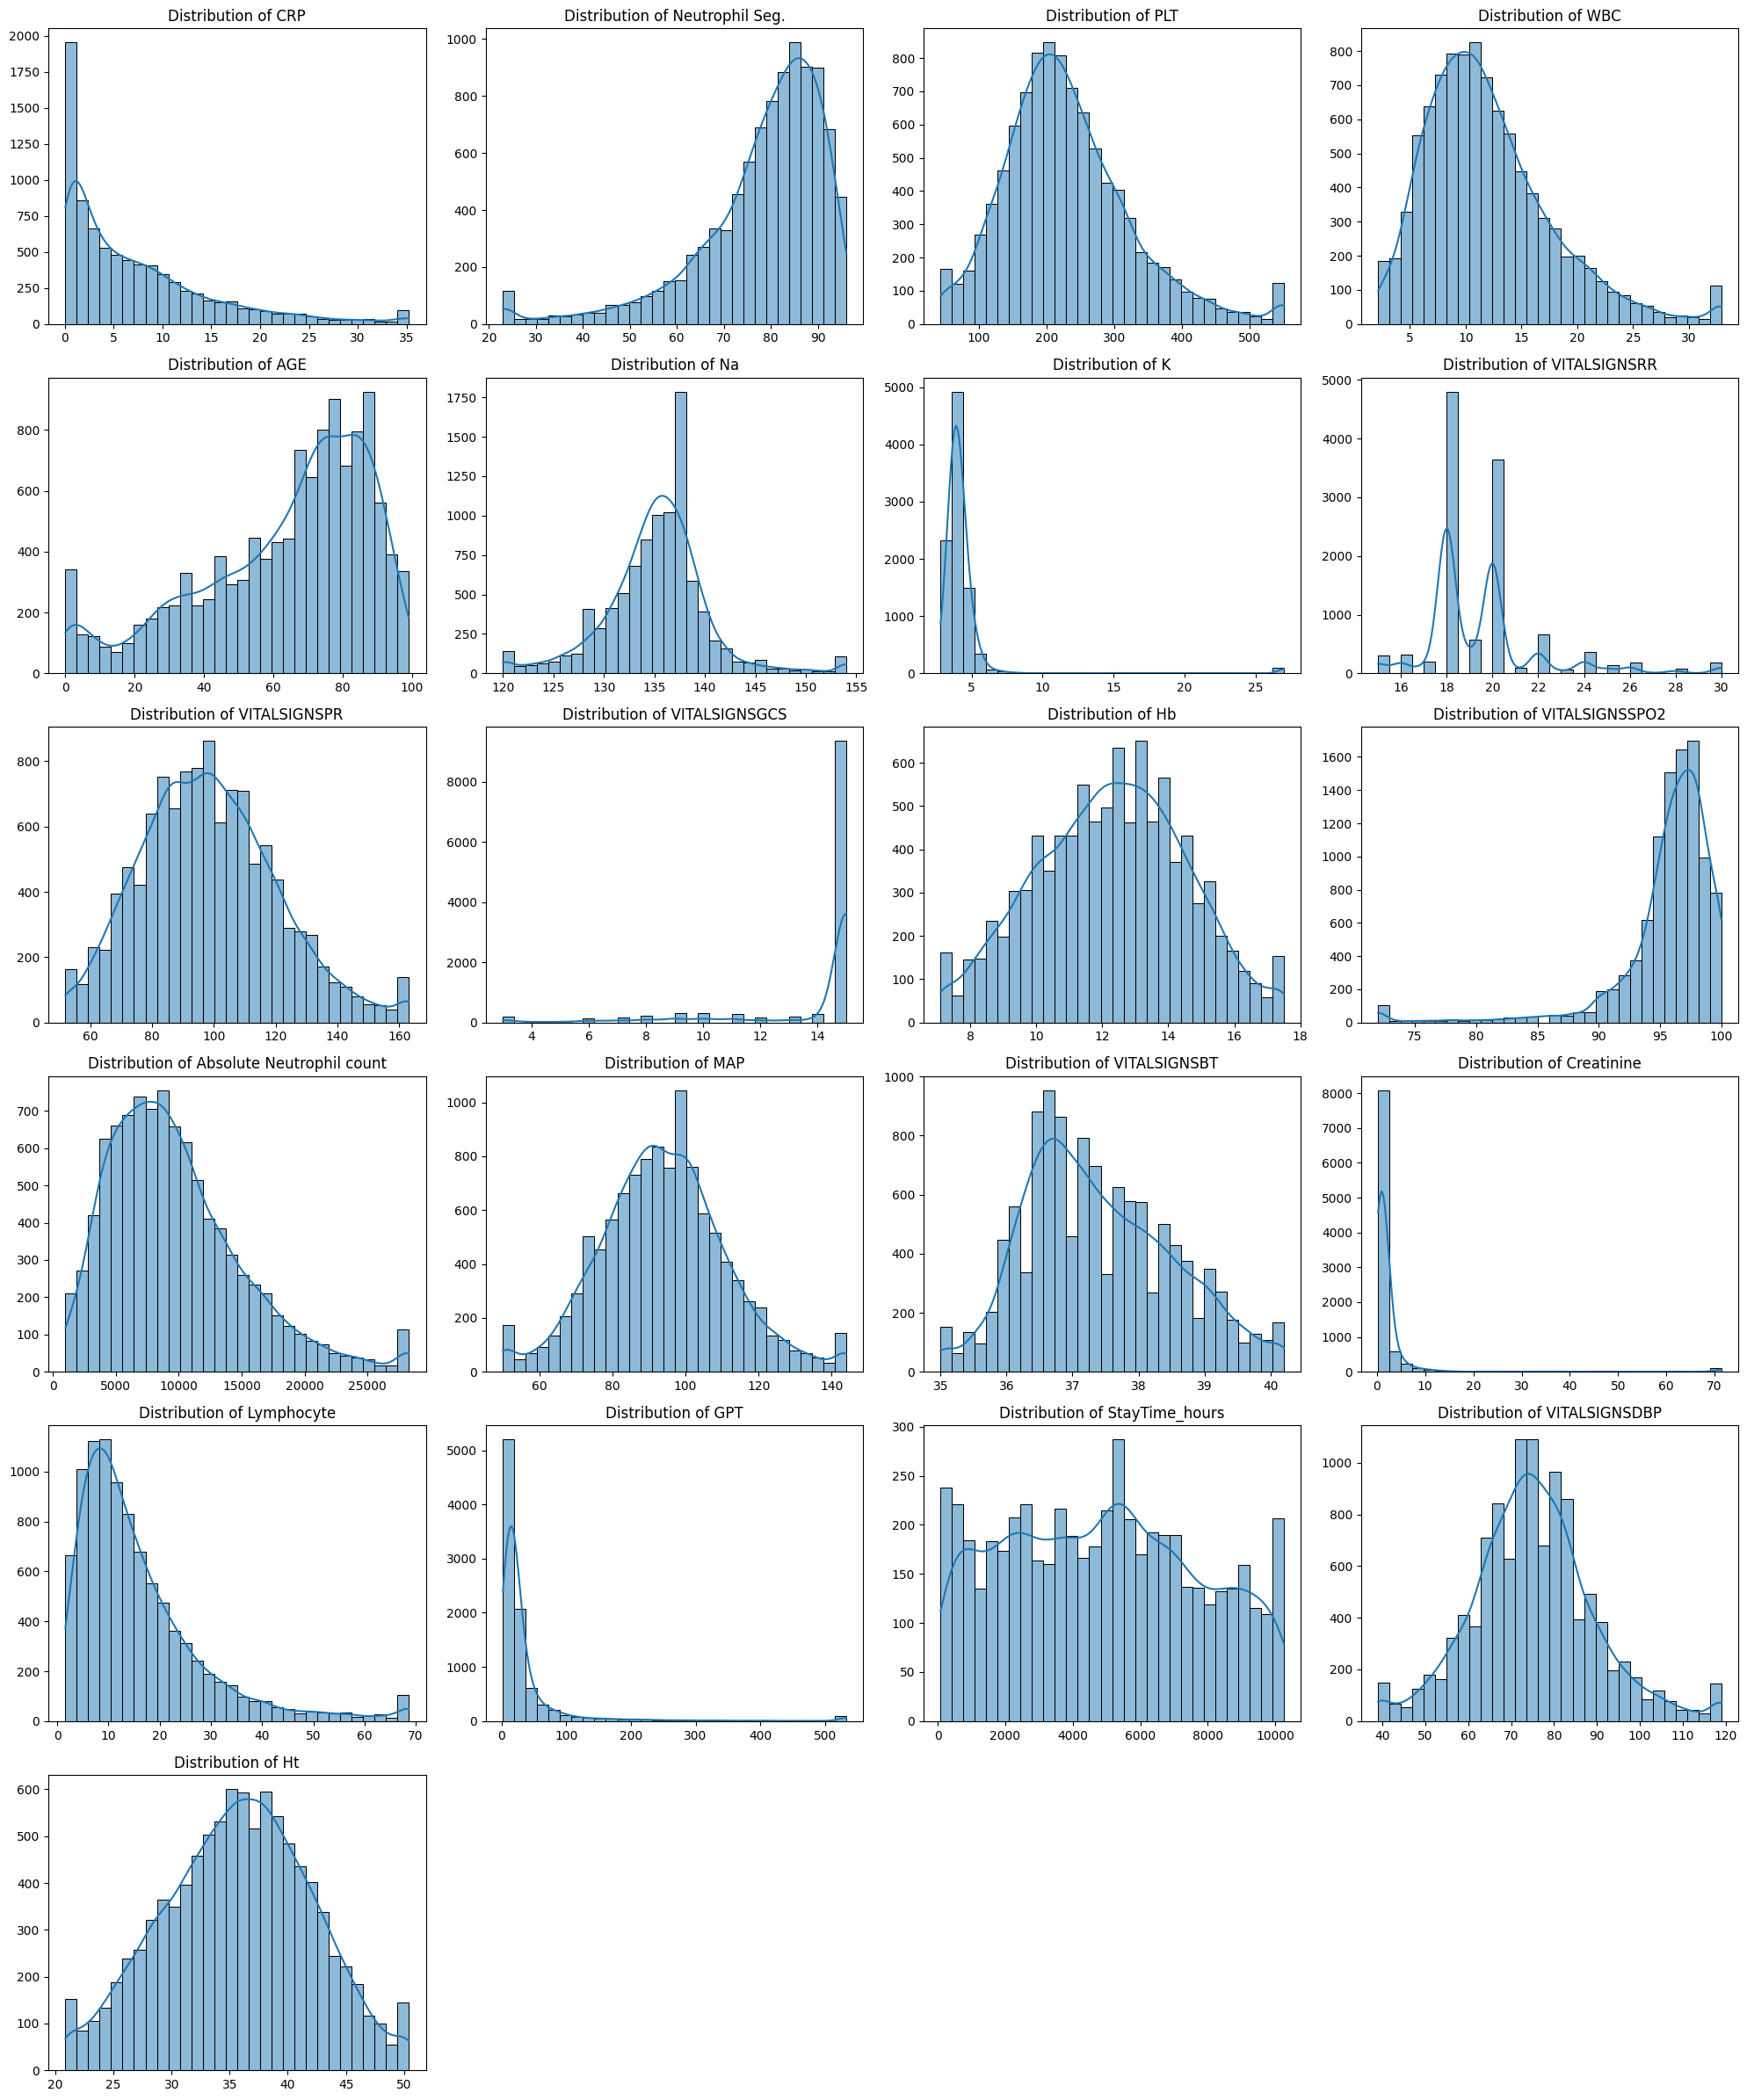

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [17]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 4051

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              116                   115   
VITALSIGNSDBP                             102                   111   
MAP                                       101                   106   
VITALSIGNSBT                               91                   101   
Absolute Neutrophil count                  96                    96   
WBC                                        95                    96   
Ht                                         97                    92   
PLT                                        93                    95   
Lymphocyte                                 87                    96   
Hb                                         89                    91   

                           Total_Outliers  
VITALSIGNSPR                          231  
VITALSIGNSDBP                         213  
MAP                                   207  
VITAL

In [18]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10692, 86), (10692, 11), (1188, 86), (1188, 11))

In [20]:
X_train.isnull().sum(), X_test.isnull().sum()

(CRP                      3333
 INFECTIONSITE1              0
 Bacteria level           6055
 Neutrophil Seg.          2117
 PLT                      2097
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 86, dtype: int64,
 CRP                      377
 INFECTIONSITE1             0
 Bacteria level           670
 Neutrophil Seg.          221
 PLT                      221
                         ... 
 CHECKITEM27_flag           0
 CHECKITEM27SCORE_flag      0
 CHECKITEM28SCORE_flag      0
 CHECKITEM31SCORE_flag      0
 CHECKITEM32SCORE_flag      0
 Length: 86, dtype: int64)

In [21]:
X_train.dtypes, X_test.dtypes

(CRP                      float64
 INFECTIONSITE1             int64
 Bacteria level           float64
 Neutrophil Seg.          float64
 PLT                      float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 86, dtype: object,
 CRP                      float64
 INFECTIONSITE1             int64
 Bacteria level           float64
 Neutrophil Seg.          float64
 PLT                      float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 86, dtype: object)

In [22]:
y_train.sum().sort_values(ascending=False)

Flomoxef                       4683.0
Amoxicillin/Clavulanic acid    1408.0
Piperacillin/Tazobactam        1358.0
Cefoperazone/sulbactam         1259.0
Metronidazole                   830.0
Ciprofloxacin                   784.0
Cefixime                        775.0
Azithromycin                    635.0
Ceftriaxone                     561.0
Cefazolin                       526.0
Levofloxacin                    453.0
dtype: float64

In [23]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

# num_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
#             'Lymphocyte', 'CRP', 'Hb', 'Creatinine', 'Leukocyte', 'PCO2', 'INR', 'Absolute Neutrophil count', 'Ht', 'HST', 'BE(ecf)', 'T.Bilirubin',
#            'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [24]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [50]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [51]:
X_train['Lymphocyte']

26125   -0.003205
23213    0.451793
15823    0.768698
18061   -0.288395
11588    1.094844
           ...   
18385   -0.200555
12239         NaN
3422     1.216037
27374    0.987415
8585     0.394679
Name: Lymphocyte, Length: 10692, dtype: float64

In [26]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [27]:
y_train.sum(axis=1).mean() # 每人平均用1.65個抗生素

1.2413019079685745

In [28]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [29]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [30]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(10692, 63)

In [31]:
# LogisticRegressionCV?
# XGBClassifier?

In [32]:
# base_model = LogisticRegressionCV (penalty='l1',
#                                    cv=3,
#                                    class_weight='balanced',
#                                    solver='liblinear',
#                                    max_iter=200,
#                                    random_state=123)

# base_model = RandomForestClassifier(
#                                     n_estimators=800, 
#                                     class_weight='balanced',
#                                     min_samples_leaf=5,
#                                     min_samples_split=10,
#                                     max_depth=15,
#                                     n_jobs=-1,
#                                     random_state=123)

base_model = XGBClassifier(n_estimators=300,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=1,
                           reg_lambda=0,
                           min_child_weight=1,
                           random_state =123,
                           n_jobs=-1
    )

multi_model = MultiOutputClassifier(base_model)
# multi_model = ClassifierChain(base_model, order='random', random_state =123)
multi_model.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [33]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.7221095334685599
0.6580381314491878


In [34]:
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])

threshold = 0.3
y_pred = (y_prob_list > threshold).astype(int)

# y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

In [35]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5223061084420041
0.33542182329810505


In [36]:
hamming_loss(y_test, y_pred)

0.10651974288337925

In [37]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.4569163860830527

In [38]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    APs = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        score = 0
        hits = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)
        APs.append(score / min(len(actual), k))
    return np.mean(APs)

In [39]:
hit3 = hit_rate_at_k(y_test.values, y_prob_list, k=3)
print('Hit@3: ', hit3)

Hit@3:  0.7946127946127947


In [40]:
precision3 = precision_at_k(y_test.values, y_prob_list, k=3)
print('precision@3: ', precision3)

precision@3:  0.30639730639730434


In [41]:
recall_3 = recall_at_k(y_test.values, y_prob_list, k=3)
print('Recall@3: ', recall_3)

Recall@3:  0.7746215494211931


In [42]:
map_3 = map_at_k(y_test.values, y_prob_list, k=3)
print('MAP@3: ', map_3)

MAP@3:  0.37721381220935984


In [43]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      1015
         1.0       0.75      0.75      0.75       173

    accuracy                           0.93      1188
   macro avg       0.85      0.85      0.85      1188
weighted avg       0.93      0.93      0.93      1188

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      1128
         1.0       0.19      0.10      0.13        60

    accuracy                           0.93      1188
   macro avg       0.57      0.54      0.55      1188
weighted avg       0.91      0.93      0.92      1188

-- Cefazolin --
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      1125
         1.0       0.62      0.24      0.34        63

    accuracy                           0.95      1188
   macro avg       0.79      0.62      0.66      1188
weigh

In [44]:
importance_all = []

for i, drug in enumerate(y_train.columns):
    
    model = multi_model.estimators_[i]
    
    # 建立 Series 並與特徵名稱對應
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )

    imp_df = imp.reset_index()
    imp_df.columns = ['feature','importance']
    imp_df['drug'] = drug
    
    imp_df_sorted = imp_df.sort_values("importance", ascending=False)
    
    print(f"=== Drug: {drug} (Top 10 Features) ===")
    print(imp_df_sorted.head(10).to_string(index=False)) # 不印索引比較美觀
    print("-" * 40)
    
    importance_all.append(imp_df_sorted)

importance_all = pd.concat(importance_all)

=== Drug: Amoxicillin/Clavulanic acid (Top 10 Features) ===
              feature  importance                        drug
       INFECTIONSITE5    0.141852 Amoxicillin/Clavulanic acid
       INFECTIONSITE1    0.079386 Amoxicillin/Clavulanic acid
       INFECTIONSITE2    0.069119 Amoxicillin/Clavulanic acid
       INFECTIONSITE3    0.053505 Amoxicillin/Clavulanic acid
                  AGE    0.053438 Amoxicillin/Clavulanic acid
            HCO3_flag    0.036898 Amoxicillin/Clavulanic acid
       INFECTIONSITE9    0.030014 Amoxicillin/Clavulanic acid
 Leukocyte level_flag    0.023483 Amoxicillin/Clavulanic acid
CHECKITEM30SCORE_flag    0.022868 Amoxicillin/Clavulanic acid
              PT_flag    0.021629 Amoxicillin/Clavulanic acid
----------------------------------------
=== Drug: Azithromycin (Top 10 Features) ===
              feature  importance         drug
       INFECTIONSITE1    0.238051 Azithromycin
              PT_flag    0.065087 Azithromycin
       INFECTIONSITE3    0.0609

In [45]:
importance_summary = importance_all.groupby('feature')['importance'].mean().sort_values(ascending=False)

print(importance_summary)

feature
INFECTIONSITE2                0.087553
INFECTIONSITE1                0.072549
INFECTIONSITE5                0.044913
PT_flag                       0.040741
APTT_flag                     0.038696
                                ...   
Bacteria level_flag           0.008835
CHECKITEM27SCORE_flag         0.008179
Microscopic RBC level_flag    0.000783
PH_flag                       0.000000
Microscopic WBC level_flag    0.000000
Name: importance, Length: 63, dtype: float32
